## 导入包

In [1]:
import os
import datetime
import argparse
import numpy as np
import torch as th
import torch.distributed as dist
import matplotlib.pyplot as plt
from pathlib import Path

from improved_diffusion import dist_util, logger
from improved_diffusion.dataset import get_dataloader, yield_dataloader, show_dataloader, show_samples
from improved_diffusion.resample import create_named_schedule_sampler
from improved_diffusion.script_util import (
    model_and_diffusion_defaults,
    create_model_and_diffusion,
    args_to_dict,
    add_dict_to_argparser,
)
from improved_diffusion.losses import compute_F1_score
from improved_diffusion.train_util import TrainLoop

## 参数设置

In [2]:
def create_argparser():
    defaults = model_and_diffusion_defaults()
    
    my_config = dict(
        root_folder_data_train = Path('../datasets/PPD/train'),
        folder_Mo_train ='MAP_with_start_end',
        folder_P_train ='PATH_2PIXEL',
        num_images_train = 12000,

        root_folder_data_sample = Path('../datasets/PPD/test/UNSEEN'),
        folder_Mo_sample ='MAP_with_start_end',
        folder_P_sample ='PATH_2PIXEL',
        num_images_sample = 1200,

        batch_size=8,
        image_size=128,
        
        biased_initialization = False,  # 是否使用 偏置初始化-范式P2
        Path_inverse = True,            # 路径是否反相，似乎 反相 的效果更好
        weight_path_similarity = 0,     # 路径相似度损失，要求恢复的图像和路径尽可能相似
        use_MFF_MAC = False,             # 是否使用 MFF_MAC

        schedule_sampler="loss-second-moment",     
        lr=1e-4,                        # Adamw的学习率
        weight_decay=0.0,               # Adamw的权重衰减
        lr_anneal_steps=20000,
        microbatch=-1,                  # -1 disables microbatches
        ema_rate="0.999",               # comma-separated list of EMA values
        resume_checkpoint="",
        use_fp16=False,
        fp16_scale_growth=1e-3,
    )
    
    defaults.update(my_config)
    parser = argparse.ArgumentParser()
    add_dict_to_argparser(parser, defaults)
    return parser
    
args = create_argparser().parse_args([])    # 模拟终端输入，但不传入任何参数
os.makedirs('../work_dirs', exist_ok=True)
# 设置 保存模型和日志地址 的环境变量
if "OPENAI_LOGDIR" not in os.environ:
    subdir = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S") + f'-P2_{args.biased_initialization}-path_simil{args.weight_path_similarity}-use_MFF_MAC-{args.use_MFF_MAC}-{args.folder_P_train}-path_inv_{args.Path_inverse}-img{args.image_size}-batch_{args.batch_size}-epochs{args.lr_anneal_steps}'
    os.environ["OPENAI_LOGDIR"] = os.path.join(os.path.expanduser("~/DiffRP_IDDPM/my_model_checkpoints"), subdir)


args.log_interval=args.lr_anneal_steps/20
args.save_interval=args.lr_anneal_steps/20

train = True
# train = False

## 配置logger，创建网络、扩散模型、dataloader

Logging to /home/pengs/DiffRP_IDDPM/my_model_checkpoints/2026-04-19-11-48-10-P2_False-path_simil0-use_MFF_MAC-False-PATH_2PIXEL-path_inv_True-img128-batch_8-epochs20000
creating model_train and diffusion_train (use MFF/MCA:False)...
creating dataloader_train...
成功加载 12000 对图片,M_o的尺寸为 (C, H, W): torch.Size([1, 128, 128]);M_r的尺寸为 (C, H, W): torch.Size([3, 128, 128]);P的尺寸为 (C, H, W): torch.Size([1, 128, 128])


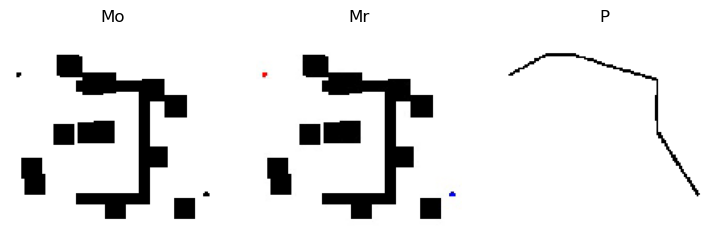

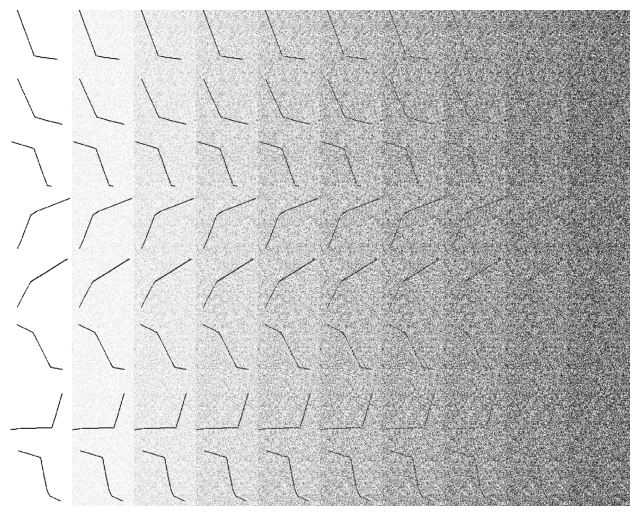

In [3]:
dist_util.setup_dist()  # 设置分布式训练环境，确保在多GPU或多节点环境下正确地初始化通信和资源分配
logger.configure()      # The logs and saved models will be written to a logging directory determined by the OPENAI_LOGDIR environment variable. If it is not set, then a temporary directory will be created in /tmp.

# 创建一个 U-Net 模型，并同时初始化一个 GaussianDiffusion 对象（负责加噪和采样逻辑）
logger.log(f"creating model_train and diffusion_train (use MFF/MCA:{args.use_MFF_MAC})...")
model_train, diffusion_train = create_model_and_diffusion(
    **args_to_dict(args, model_and_diffusion_defaults().keys())
)
model_train.to(dist_util.dev())
schedule_sampler = create_named_schedule_sampler(args.schedule_sampler, diffusion_train)  # 重要性采样器

logger.log("creating dataloader_train...")
dataloader_train = get_dataloader(args.root_folder_data_train, args.folder_Mo_train, args.folder_P_train, args.Path_inverse, args.num_images_train, args.batch_size, args.image_size, shuffle = True)


show_dataloader(dataloader_train)
diffusion_train.extract_forward(dataloader_train, device='cpu', n_steps=1000)

## 训练

In [ ]:
# 创建训练过程中的临时推理DDIM，用于展示训练结果
args.clip_denoised = True
args.use_ddim = True
args.timestep_respacing = "ddim20"
_, diffusion_sample = create_model_and_diffusion(
    **args_to_dict(args, model_and_diffusion_defaults().keys())
)
# 固定M_o
dataloader_sample = get_dataloader(args.root_folder_data_sample, args.folder_Mo_sample, args.folder_P_sample, args.Path_inverse, args.num_images_sample, args.batch_size, args.image_size, shuffle = False)
sample_Mo, sample_Mr, sample_P, _, _ = next(iter(dataloader_sample))

if train:
    logger.log("training...")
    TrainLoop(
        model=model_train,
        diffusion=diffusion_train,
        sample_diffusion = diffusion_sample,
        Path_inverse = args.Path_inverse,
        weight_path_similarity = args.weight_path_similarity,
        sample_Mo = sample_Mo,
        sample_Mr = sample_Mr,
        sample_P = sample_P,
        data=yield_dataloader(dataloader_train),    # 训练数据的生成器，提供训练过程中需要的图像和对应的条件信息（如果有的话）
        batch_size=args.batch_size,
        microbatch=args.microbatch,
        lr=args.lr,                                 # Adam学习率
        ema_rate=args.ema_rate,                     # 指数移动平均（EMA）的衰减率，EMA是一种在训练过程中对模型参数进行平滑处理的方法，可以帮助模型在训练过程中更稳定地收敛，并且在评估和生成阶段通常能得到更好的性能
        log_interval=args.log_interval,             # 日志记录的频率，单位是训练步骤数，例如 log_interval=10 表示每训练10步记录一次日志
        save_interval=args.save_interval,           # 保存模型的频率，单位是训练步骤数，例如 save_interval=10000 表示每训练10000步保存一次模型
        resume_checkpoint=args.resume_checkpoint,   # 续训的检查点路径，如果提供了这个参数，训练将从指定的检查点继续，而不是从头开始。这对于长时间训练或在中途需要暂停训练的情况非常有用。
        use_fp16=args.use_fp16,                     # 是否使用半精度（FP16）训练，使用FP16可以减少显存占用并加速训练，但可能会导致数值不稳定，特别是在某些模型架构或训练设置下。
        fp16_scale_growth=args.fp16_scale_growth,
        schedule_sampler=schedule_sampler,          # 重要性采样器的类型，默认是 "uniform"，表示在训练过程中均匀地采样时间步长。其他选项可能包括 "loss-second-moment"，它根据模型在不同时间步长上的损失来调整采样概率，以提高训练效率。
        weight_decay=args.weight_decay,             # AdamW优化器中的权重衰减（Weight Decay）参数，控制模型参数更新时的L2正则化强度，增加权重衰减可以帮助模型防止过拟合，但过高的权重衰减可能会导致模型欠拟合。
        lr_anneal_steps=args.lr_anneal_steps,       # 如果 lr_anneal_steps 设为 0（默认通常如此），训练循环将永远运行下去，直到你手动停止。
    ).run_loop()

成功加载 1200 对图片,M_o的尺寸为 (C, H, W): torch.Size([1, 128, 128]);M_r的尺寸为 (C, H, W): torch.Size([3, 128, 128]);P的尺寸为 (C, H, W): torch.Size([1, 128, 128])
training...
--------------------------------
| F1                | 0.0329   |
| F1(EMA)           | 0.0327   |
| grad_norm         | 2.87     |
| loss              | 0.997    |
| loss_q0           | 0.994    |
| loss_q1           | 0.995    |
| loss_q2           | 0.995    |
| loss_q3           | 1.01     |
| mse               | 0.997    |
| mse_q0            | 0.994    |
| mse_q1            | 0.995    |
| mse_q2            | 0.995    |
| mse_q3            | 1.01     |
| Path_simi_loss    | 0        |
| Path_simi_loss_q0 | 0        |
| Path_simi_loss_q1 | 0        |
| Path_simi_loss_q2 | 0        |
| Path_simi_loss_q3 | 0        |
| samples           | 8        |
| step              | 0        |
| test_loss         | 0        |
| test_loss(EMA)    | 0        |
--------------------------------
saving model 0
saving model 0.999
---------------

## 推理

loading trained state dict...
creating model and diffusion...
use_timesteps in GaussianDiffusion is {0, 900, 650, 400, 150, 800, 550, 300, 50, 950, 700, 450, 200, 850, 600, 350, 100, 750, 500, 250}
creating data loader...
成功加载 1200 对图片,M_o的尺寸为 (C, H, W): torch.Size([1, 128, 128]);M_r的尺寸为 (C, H, W): torch.Size([3, 128, 128]);P的尺寸为 (C, H, W): torch.Size([1, 128, 128])


/home/pengs/DiffRP_IDDPM/improved_diffusion/dist_util.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return th.load(io.BytesIO(data), **kwargs)


sampling...
F1 = 0.03217510133981705
created 8 samples
saving to /home/pengs/DiffRP_IDDPM/my_model_checkpoints/2026-04-19-11-41-40-P2_False-path_simil0-use_MFF_MAC-False-PATH_2PIXEL-path_inv_True-img128-batch_8-epochs100/samples_8x128x128x1.npz
sampling complete


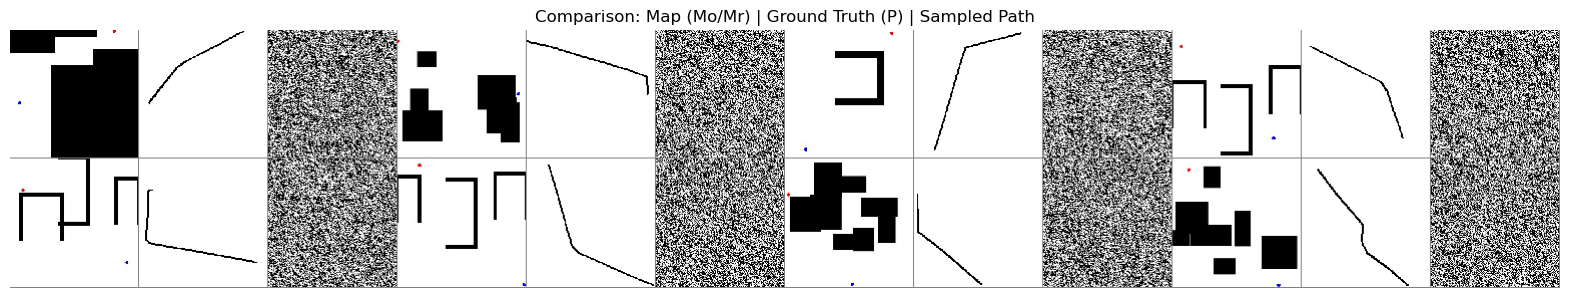

('659.jpg', '1198.jpg', '75.jpg', '484.jpg', '579.jpg', '321.jpg', '960.jpg', '1065.jpg')


In [ ]:
# 设置推理参数
args.clip_denoised = True
args.num_samples = args.batch_size
args.use_ddim = True
args.timestep_respacing = "ddim20"


logger.log("loading trained state dict...")
if train:
    model_path=os.path.join(os.environ["OPENAI_LOGDIR"], 'model.pt' )
else:
    model_path='../my_model_checkpoints/model.pt'

logger.log(f"creating model_sample and diffusion_sample (use MFF/MCA:{args.use_MFF_MAC})...")
model, diffusion = create_model_and_diffusion(
    **args_to_dict(args, model_and_diffusion_defaults().keys())
)

model.load_state_dict(
    dist_util.load_state_dict(model_path, map_location="cpu")
)
model.to(dist_util.dev())
model.eval()

logger.log("creating data loader_sample...")
dataloader = get_dataloader(args.root_folder_data_sample, args.folder_Mo_sample, args.folder_P_sample, args.Path_inverse, args.num_images_sample, args.batch_size, args.image_size)
M_o, M_r, P, _, img_name = next(iter(dataloader))

logger.log("sampling...")
all_images = []
all_labels = []
while len(all_images) * args.batch_size < args.num_samples:
    model_kwargs = {}
    sample = diffusion.ddim_sample_loop(
        model,
        M_o,
        M_r,
        M_o.shape,
        clip_denoised=args.clip_denoised,
        model_kwargs=model_kwargs,
    )
    f1 = compute_F1_score(P.to(dist_util.dev()), sample.to(dist_util.dev()), args.Path_inverse, thresh_hold=0)
    print(f'F1 = {f1}')

    sample = ((sample + 1) * 127.5).clamp(0, 255).to(th.uint8)
    sample = sample.permute(0, 2, 3, 1)
    sample = sample.contiguous()

    gathered_samples = [th.zeros_like(sample) for _ in range(dist.get_world_size())]
    dist.all_gather(gathered_samples, sample)  # gather not supported with NCCL
    all_images.extend([sample.cpu().numpy() for sample in gathered_samples])
    logger.log(f"created {len(all_images) * args.batch_size} samples")

arr = np.concatenate(all_images, axis=0)
arr = arr[: args.num_samples]
if args.class_cond:
    label_arr = np.concatenate(all_labels, axis=0)
    label_arr = label_arr[: args.num_samples]
if dist.get_rank() == 0:
    shape_str = "x".join([str(x) for x in arr.shape])
    out_path = os.path.join(logger.get_dir(), f"samples_{shape_str}.npz")
    logger.log(f"saving to {out_path}")
    if args.class_cond:
        np.savez(out_path, arr, label_arr)
    else:
        np.savez(out_path, arr)

dist.barrier()
logger.log("sampling complete")

show_samples(args, arr, M_r, P, img_name)

## DDIM反向过程展示

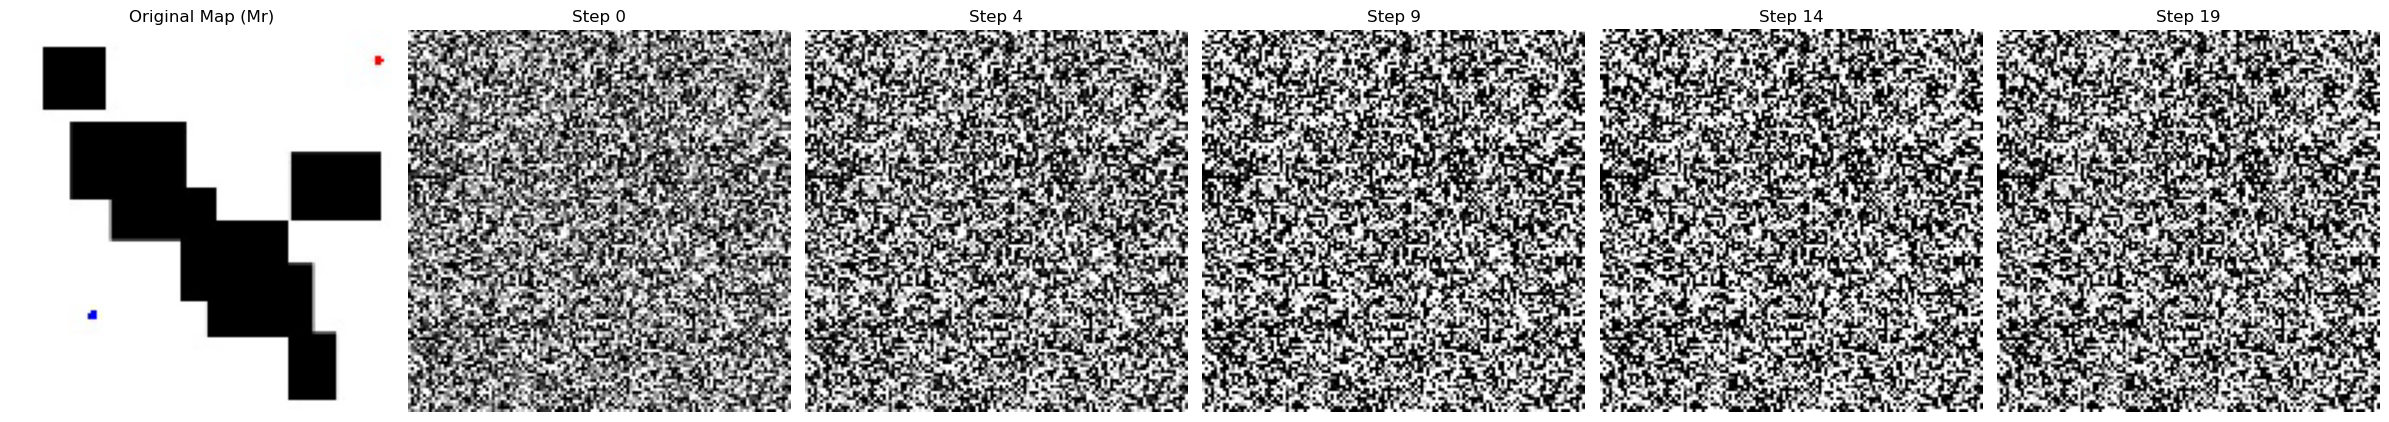

In [ ]:
# 假设你正在运行采样循环
# samples_list 用于存储中间过程
samples_list = []
steps_to_show = [0, 4, 9, 14, 19]  # 假设总共 20 步，记录这些步数
M_o, M_r, P, _, _ = next(iter(dataloader))

for i, out in enumerate(diffusion.ddim_sample_loop_progressive(
    model,
    M_o,
    M_r,
    M_o.shape,
    noise=None,
    clip_denoised=args.clip_denoised,
    denoised_fn=None,
    model_kwargs=model_kwargs,
    device=None,
    progress=False,
    eta=0.0,
)):
    if i in steps_to_show:
        # 反归一化并存入列表
        sample = ((out["sample"] + 1) * 127.5).clamp(0, 255).to(th.uint8)
        samples_list.append(sample[0, 0].cpu().numpy())

# 绘图展示
fig, axes = plt.subplots(1, len(samples_list) + 1, figsize=(24, 5))
Map_img = ((M_r[0].detach().cpu().permute(1, 2, 0) + 1) * 127.5).clamp(0, 255).to(th.uint8).numpy()
axes[0].imshow(Map_img)
axes[0].set_title("Original Map (Mr)")
axes[0].axis('off')

# 2. 依次画出采样过程中的中间结果
for idx, img in enumerate(samples_list):
    ax = axes[idx + 1] # 偏移一位
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Step {steps_to_show[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()
